In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os


path='C:/Users/Nicolas Catz/Documents/OpenBCI_GUI/Recordings/' # specify the path to the folder containing the data file
path='D:\\DATA\\Projets\\M1_EEG_Project\\' # specify the path to the folder containing the data file/

session='data' # specify the name of the session folder

filename='auditory_test.csv' # specify the name of the data file

data = pd.read_csv(os.path.join(path, session, filename),delimiter='\\t',header=None) # read the data file into a pandas DataFrame  

stimulus=data[13]


C:\Users\Nicolas Catz\AppData\Local\Temp\ipykernel_78344\1322459831.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(os.path.join(path, session, filename),delimiter='\\t',header=None) # read the data file into a pandas DataFrame


In [62]:
threshold = (stimulus.max() + stimulus.min()) / 2
above = stimulus > threshold

onset_mask = above & ~above.shift(1, fill_value=False)
onsets = stimulus.index[onset_mask]

In [63]:
onsets

Index([ 1938,  2268,  2564,  2885,  3228,  3558,  3851,  4115,  4440,  4737,
       ...
       36398, 36703, 37024, 37356, 37666, 38000, 38336, 38699, 39023, 39312],
      dtype='int64', length=120)

In [64]:
eeg_data=data.iloc[:, 1:9]  # select the EEG data columns (assuming they are in columns 1 to 8)



In [65]:
from scipy.signal import butter, filtfilt, iirnotch

fs = 250
print(f"Fréquence d'échantillonnage estimée : {fs:.2f} Hz")

def bandpass_filter(sig, low=1.0, high=40.0, fs=fs, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

def notch_filter(sig, freq=50.0, fs=fs, q=30):
    nyq = fs / 2
    b, a = iirnotch(freq / nyq, q)
    return filtfilt(b, a, sig)


Fréquence d'échantillonnage estimée : 250.00 Hz


In [66]:
eeg_data=eeg_data.to_numpy()  # convert the DataFrame to a NumPy array for easier processing
eeg_data=eeg_data.T

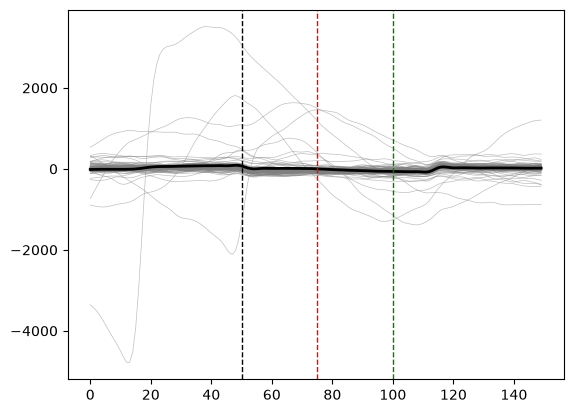

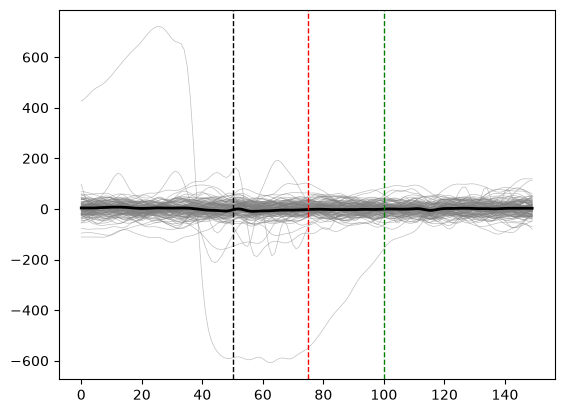

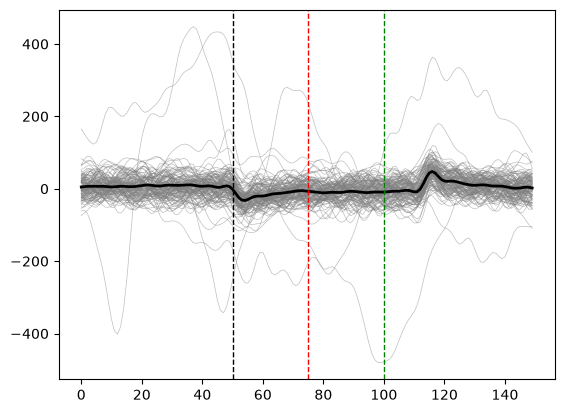

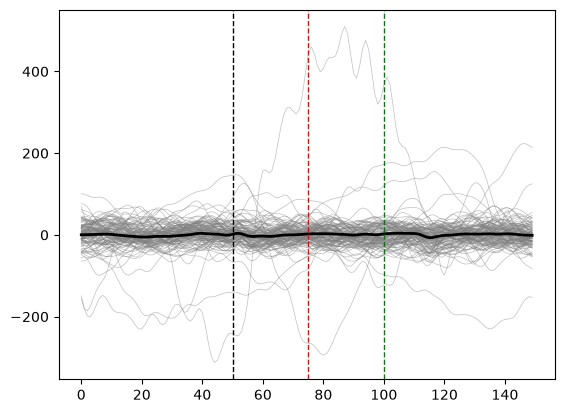

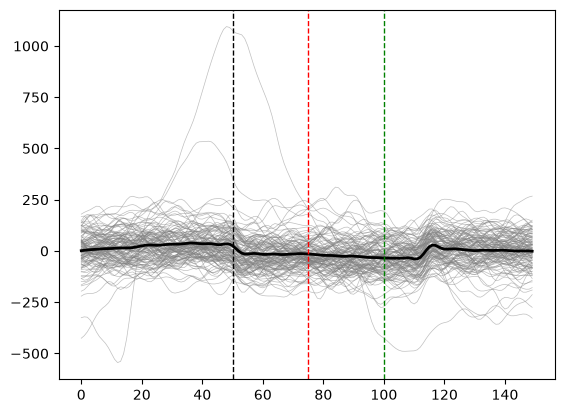

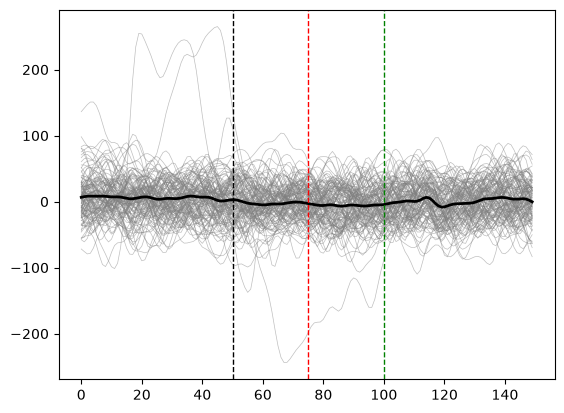

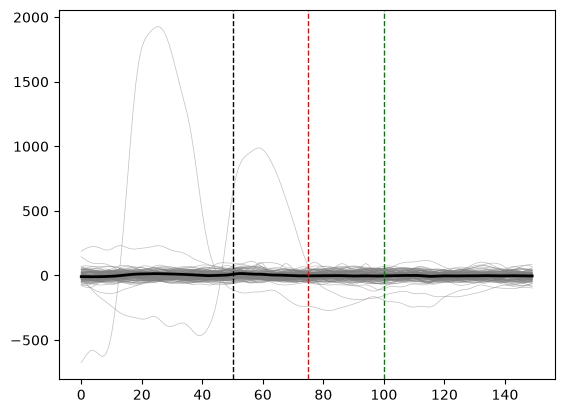

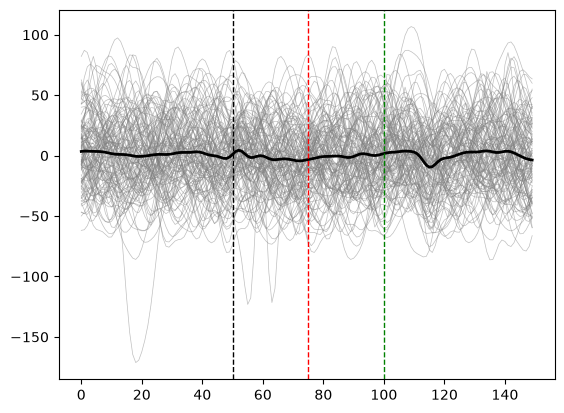

In [67]:

for channel in range(0,8):  # Only process the first channel
    
    raw_signal = eeg_data[channel, :-2]

    eeg_filtered = notch_filter(bandpass_filter(raw_signal))

    pre=50
    post=100
    eegaligned = []
    for time in onsets:
        # print(f"Aligning EEG data for channel {channel} at time {time}")
        eegaligned.append(eeg_filtered[time-pre:time+post])

        
    plt.plot(np.transpose(eegaligned),'gray', alpha=0.5,lw=0.5)
    plt.plot(np.mean(eegaligned, axis=0), 'k', linewidth=2)
    plt.axvline(50, color='black', linestyle='--', linewidth=1)
    plt.axvline(75, color='red', linestyle='--', linewidth=1)
    plt.axvline(100, color='green', linestyle='--', linewidth=1)


    plt.show()